--- Accuracy Report ---
              precision    recall  f1-score   support

           1       0.81      0.89      0.85       123
           2       0.45      0.33      0.38        30
           3       0.61      0.58      0.60        43
           4       0.00      0.00      0.00         3

    accuracy                           0.73       199
   macro avg       0.47      0.45      0.46       199
weighted avg       0.70      0.73      0.71       199



C:\Users\66851\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\66851\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\66851\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


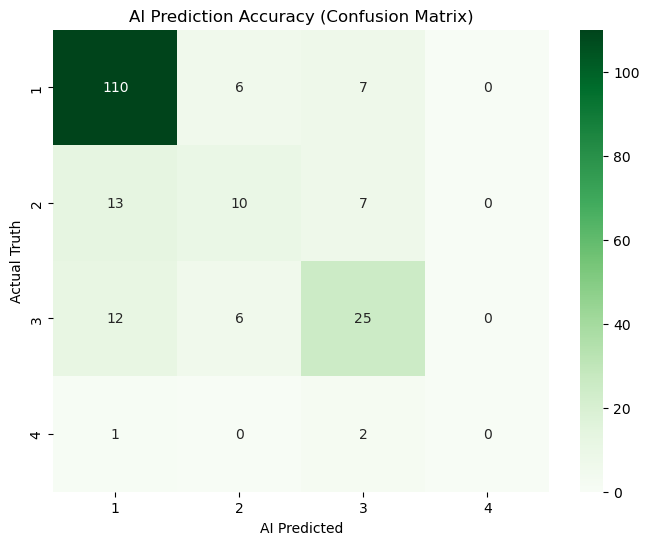

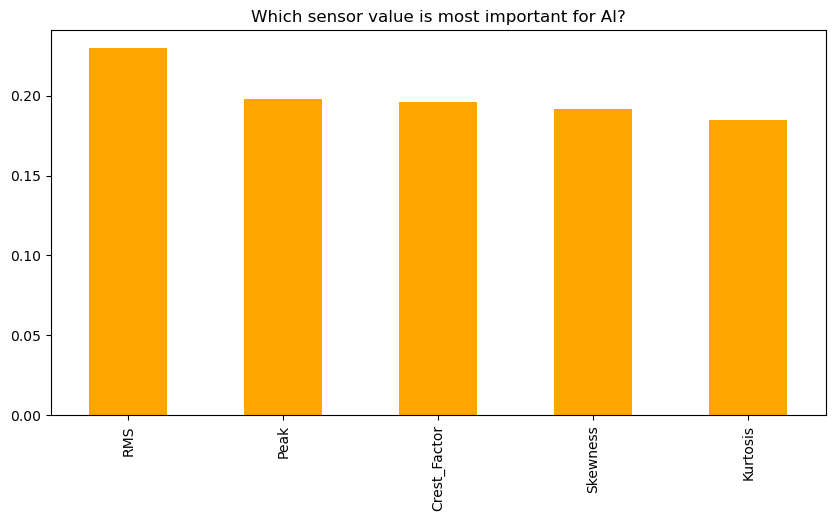

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. โหลดข้อมูลที่รวมสำเร็จ 994 แถว
df = pd.read_csv('Master_Dataset_for_ML_v2.csv')

# 2. เลือก Features (X) และสิ่งที่จะทาย (y)
features = ['RMS', 'Peak', 'Kurtosis', 'Skewness', 'Crest_Factor']
X = df[features]
y = df['Severity of bearing defect (Y13)']

# 3. แบ่งข้อมูล (Train 80%, Test 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. สร้างและฝึกสอน AI (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. วัดผลความแม่นยำ
y_pred = model.predict(X_test)

print("--- Accuracy Report ---")
print(classification_report(y_test, y_pred))

# 6. วาดกราฟดูว่า AI ทายพลาดตรงไหน (Confusion Matrix)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('AI Prediction Accuracy (Confusion Matrix)')
plt.xlabel('AI Predicted')
plt.ylabel('Actual Truth')
plt.show()

# 7. ดูว่า "ค่าสถิติ" ตัวไหนสำคัญที่สุดในการบอกว่าเครื่องพัง
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='orange')
plt.title('Which sensor value is most important for AI?')
plt.show()

In [3]:
import joblib

# สร้าง Dictionary เก็บทั้ง Model และ รายชื่อ Features
model_data = {
    'model': model,
    'features': features
}

# บันทึกไฟล์
joblib.dump(model_data, 'bearing_model.pkl')
print("✅ Save model เรียบร้อยในชื่อ 'bearing_model.pkl'")

✅ Save model เรียบร้อยในชื่อ 'bearing_model.pkl'
